In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # for data visualization
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split


In [7]:
train_data = pd.read_csv('../04_MNIST/digit-recognizer/train.csv')
test_data = pd.read_csv('../04_MNIST/digit-recognizer/test.csv')

train_data.head()


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
test_data.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
train_data.describe()# 统计数据的基本信息


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [11]:
print(train_data['label'].value_counts())# 统计每个类别的样本数量


label
1    4684
7    4401
3    4351
9    4188
2    4177
6    4137
0    4132
4    4072
8    4063
5    3795
Name: count, dtype: int64


In [12]:
train_data.shape

(42000, 785)

In [14]:
y = train_data['label'].values
X = train_data.drop('label', axis=1).values

In [15]:
y.shape, X.shape

((42000,), (42000, 784))

In [21]:
train_data.head(10)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


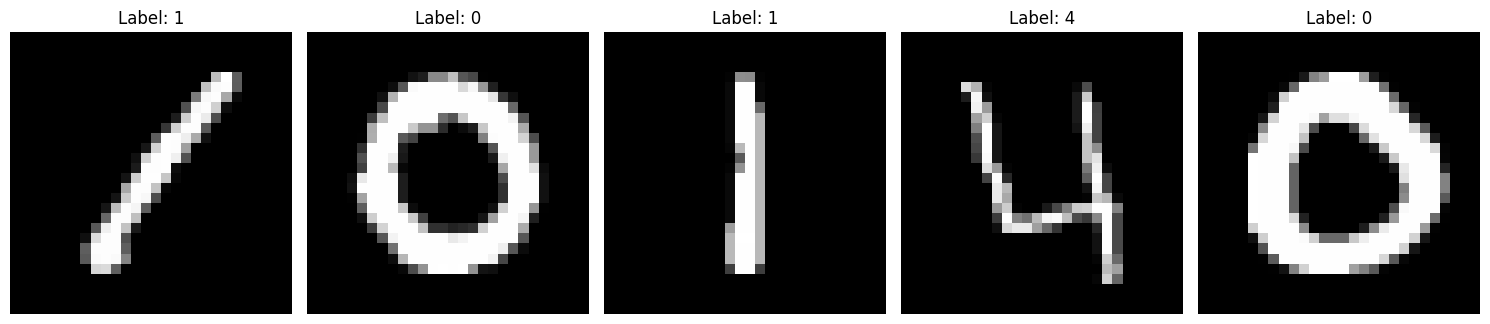

In [27]:
plt.figure(figsize=(15, 5))

for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')# 隐藏坐标轴

plt.tight_layout()
plt.show()

In [29]:
#标准化
X = X / X.max()# 将像素值缩放到0-1范围内

# 将数据转换为PyTorch张量
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

#数据加载器
dataset = TensorDataset(X_tensor, y_tensor)

# 划分训练集和验证集
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

# 使用random_split函数进行随机划分
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print(f"训练集大小: {len(train_dataset)}")
print(f"验证集大小: {len(val_dataset)}")

训练集大小: 33600
验证集大小: 8400


In [30]:
#创建 DataLoader，用于后续加载数据
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)


In [31]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1) # 输入通道数为1，输出通道数为32
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # 输入通道数为32，输出通道数为64
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # 输入通道数为64，输出通道数为128
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # 最大池化层，窗口大小为2x2,输出大小为输入的一半
        
        self.relu = nn.ReLU() # 激活函数
        
        self.fc1 = nn.Linear(128 * 3 * 3, 128) # 全连接层，输入特征数为128*3*3，输出特征数为128
        self.fc2 = nn.Linear(128, 10) # 全连接层，输入特征数为128，输出特征数为10（对应10个类别）
        

    def forward(self, x):
        x = x.view(-1, 1, 28, 28) # 将输入数据调整为4D张量，形状为(batch_size, channels, height, width)
        
        x = self.relu(self.conv1(x)) # 卷积层1 + 激活函数 输出 32x28x28
        x = self.pool(x) # 池化层1 输出 32x14x14
        
        x = self.relu(self.conv2(x)) # 卷积层2 + 激活函数 输出 64x14x14
        x = self.pool(x) # 池化层2 输出 64x7x7
        
        x = self.relu(self.conv3(x)) # 卷积层3 + 激活函数 输出 128x7x7
        x = self.pool(x) # 池化层3 输出 128x3x3
        
        x = x.view(x.size(0), -1) # 将特征图展平为2D张量，形状为(batch_size, 128*3*3)
        
        x = self.relu(self.fc1(x)) # 全连接层1 + 激活函数 输出 128
        x = self.fc2(x) # 全连接层2 输出 10
        
        return x
    
        
        

In [ ]:
model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#记录每个 epoch 的训练损失、验证损失和验证准确率
train_losses = []
val_losses = []
val_accuracies = []

#记录每一步的训练损失
train_losses_per_step = []





In [34]:
from tqdm import tqdm

In [39]:
# 训练过程

num_epochs = 15

for epoch in range(num_epochs):
    #1. 训练阶段
    model.train()
    running_loss = 0.0 # 用于累积每个 epoch 的训练损失
    
    for i, (inputs, labels) in tqdm(enumerate(train_loader), total=len(train_loader),
                                    desc=f"Epoch {epoch+1}/{num_epochs}"):
        inputs = inputs.view(-1, 28*28)
        
        optimizer.zero_grad() # 清空梯度
        outputs = model(inputs) # 前向传播
        loss = criterion(outputs, labels) # 计算损失
        loss.backward() # 反向传播
        optimizer.step() # 更新参数
        
        running_loss += loss.item() # 累积损失
        train_losses_per_step.append(loss.item()) # 记录每一步的训练损失
        
        if (i + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}")
    
    avg_train_loss = running_loss / len(train_loader) # 计算平均训练损失
    train_losses.append(avg_train_loss) # 记录每个 epoch 的平均训练损失
    
    #2. 验证阶段
    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():# 在验证阶段不计算梯度
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
            inputs = inputs.view(-1, 28*28)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1) # 获取预测结果
            total += labels.size(0) # 累积总样本数
            correct += (predicted == labels).sum().item() # 累积正确预测数
    
    avg_val_loss = running_val_loss / len(val_loader) # 计算平均验证损失
    val_losses.append(avg_val_loss) # 记录每个 epoch 的平均验证损失
    val_accuracy = correct / total # 计算验证准确率
    val_accuracies.append(val_accuracy) # 记录每个 epoch 的验证准确率
    
    

    
        

Epoch 1/15:  20%|█▉        | 104/525 [00:02<00:11, 36.39it/s]

Epoch [1/15], Step [100/525], Loss: 0.0087


Epoch 1/15:  39%|███▉      | 204/525 [00:05<00:08, 36.58it/s]

Epoch [1/15], Step [200/525], Loss: 0.0404


Epoch 1/15:  58%|█████▊    | 304/525 [00:08<00:06, 35.98it/s]

...

Epoch 15/15:  77%|███████▋  | 404/525 [00:10<00:03, 36.70it/s]

Epoch [15/15], Step [400/525], Loss: 0.0001


Epoch 15/15:  96%|█████████▌| 504/525 [00:13<00:00, 36.49it/s]

Epoch [15/15], Step [500/525], Loss: 0.0016


Epoch 15/15 - Validation: 100%|██████████| 132/132 [00:01<00:00, 131.75it/s]


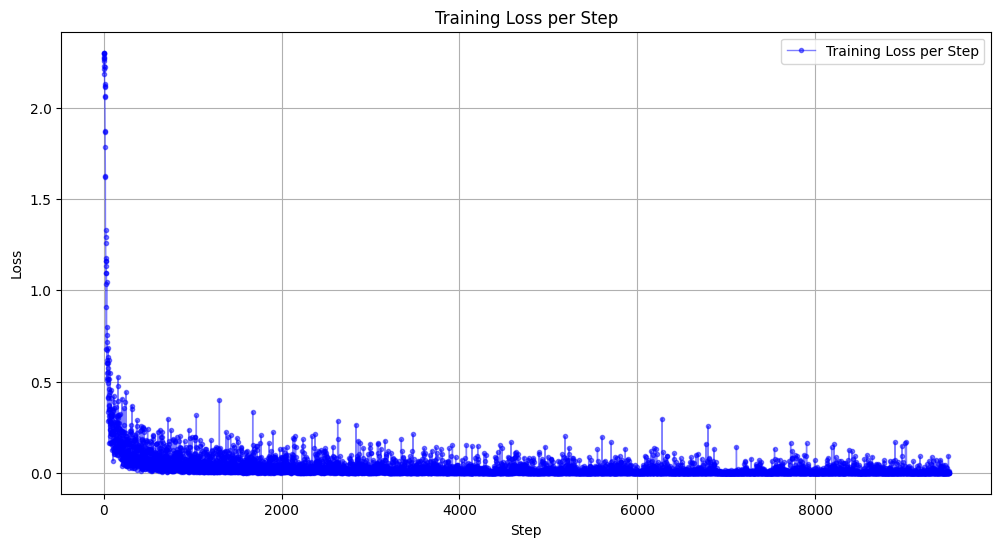

In [40]:
#绘制每一步的训练损失曲线
plt.figure(figsize=(12, 6))
plt.plot(train_losses_per_step, label='Training Loss per Step', color='blue', alpha=0.5,marker='o', markersize=3, linewidth=1)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss per Step')
plt.legend()
plt.grid()
plt.show()

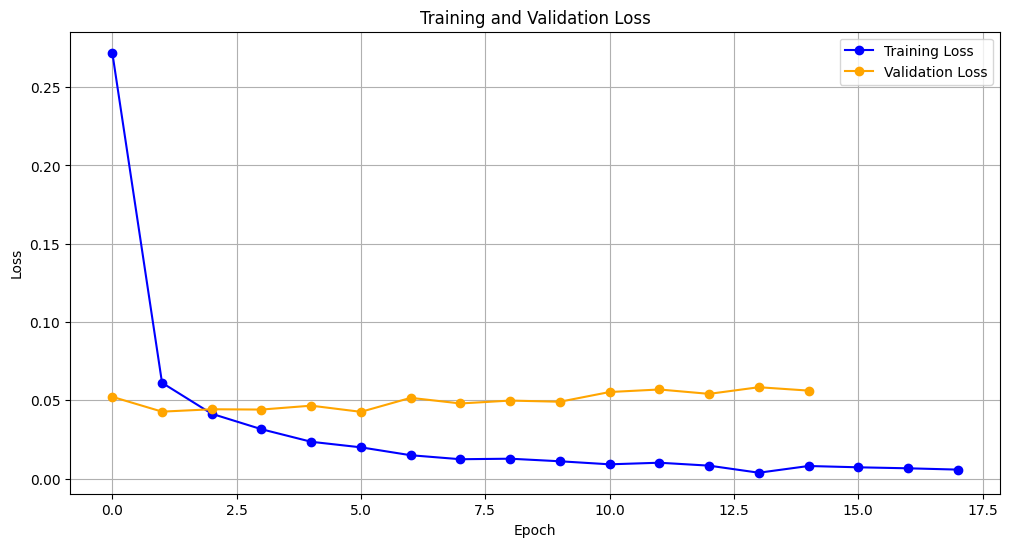

In [41]:
#绘制损失曲线
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Training Loss', color='blue', marker='o')
plt.plot(val_losses, label='Validation Loss', color='orange', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid()
plt.show()  

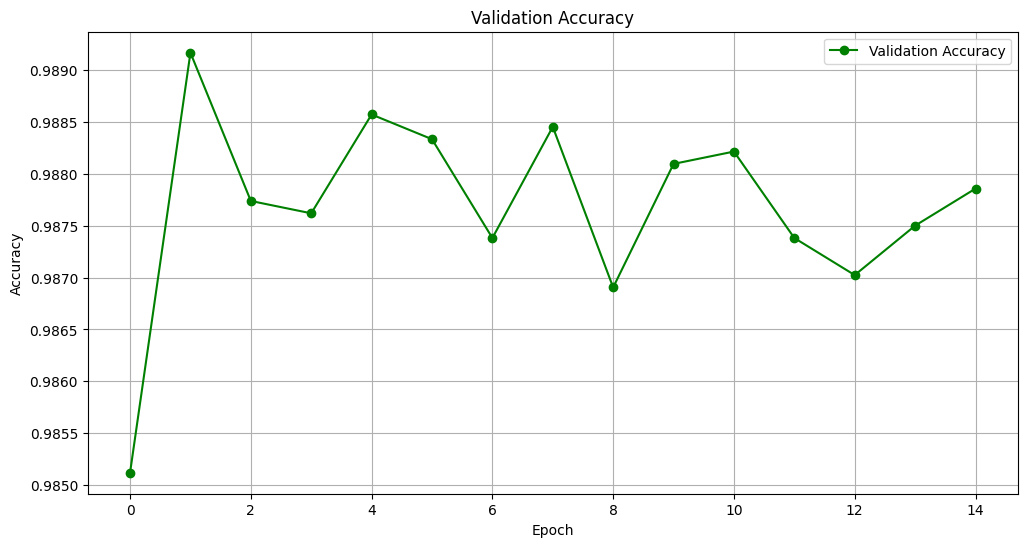

In [42]:
#绘制验证准确率曲线
plt.figure(figsize=(12, 6))
plt.plot(val_accuracies, label='Validation Accuracy', color='green', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()
plt.grid()
plt.show()

In [48]:
X_test = test_data.values# 标准化测试数据
X_test = X_test / 255.0 # 将像素值缩放到0-1范围内

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

test_dataset = TensorDataset(X_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model.eval()

all_images = []
all_predictions = []

with torch.no_grad():
    for inputs in tqdm(test_loader, desc="Predicting on Test Set"):
        inputs = inputs[0].view(-1, 28*28) # 调整输入形状
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1) # 获取预测结果
        
        all_images.extend(inputs.view(-1, 28, 28).cpu().numpy()) # 将输入图像保存到列表中
        all_predictions.extend(predicted.cpu().numpy()) # 将预测结果保存到列表中

all_predictions[:5]

Predicting on Test Set: 100%|██████████| 438/438 [00:03<00:00, 128.77it/s]


[np.int64(2), np.int64(0), np.int64(9), np.int64(9), np.int64(3)]

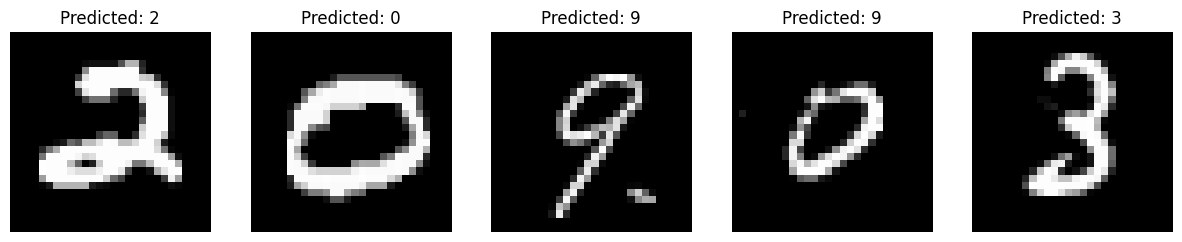

In [49]:
#选择前5张测试图像进行可视化
num_images_to_show = 5
fig, axes = plt.subplots(1, 5, figsize=(15, 6))
for i in range(num_images_to_show):
    axes[i].imshow(all_images[i], cmap='gray')
    axes[i].set_title(f"Predicted: {all_predictions[i]}")
    axes[i].axis('off') # 隐藏坐标轴

In [50]:
image_ids = range(1, len(all_predictions) + 1) # 创建图像ID，从1开始
image_ids

range(1, 28001)

In [51]:
results_df = pd.DataFrame({
    'ImageId': image_ids,
    'Label': all_predictions
})
results_df.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3


In [52]:
results_df.to_csv('mnist_cnn_predictions.csv', index=False)
print("预测结果已保存到 mnist_cnn_predictions.csv 文件中。")


预测结果已保存到 mnist_cnn_predictions.csv 文件中。


In [53]:
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc="Collecting True and Predicted Labels"):
        inputs = inputs.view(-1, 28*28)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1) # 获取预测结果
        
        y_true.extend(labels.cpu().numpy()) # 将真实标签保存到列表中
        y_pred.extend(predicted.cpu().numpy()) # 将预测结果保存到列表中
        
from sklearn.metrics import confusion_matrix, f1_score

cm = confusion_matrix(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='weighted') 
print("Confusion Matrix:")
print(cm)
print(f"F1 Score: {f1:.4f}") 


Confusion Matrix:
[[850   0   1   1   0   0   0   0   0   1]
 [  0 906   0   1   0   0   0   2   0   0]
 [  0   3 817   2   0   0   0   2   1   0]
 [  0   0   0 865   0   0   0   2   1   1]
 [  0   0   0   0 808   0   1   3   0   3]
 [  0   0   0   9   0 770   2   1   1   1]
 [  1   0   0   1   1   2 810   0   1   0]
 [  0   3   5   7   0   0   0 870   1   0]
 [  1   2   1   4   2   2   4   0 785   7]
 [  0   1   0   2   3   2   0   7   3 817]]
F1 Score: 0.9879
